# 02 · Reference engine

**ORB study, notebook 2 of 5.** Question: does the engine do exactly what the pre-registration says, bar by bar,
without looking ahead?

The rules are in [PREREGISTRATION.md](PREREGISTRATION.md) section 3 and the docstring of `orb_engine.py`. In one
paragraph: the opening range is the high H and low L of the first *m* one-minute bars after the anchor. A close
entry triggers on the first completed bar closing beyond H or L and fills at the next bar's open; a resting stop
entry fills at the level or a worse open. The protective stop is live from the fill; a bar opening beyond it exits
at that open, otherwise a touch exits at the stop. A bar that could order two events either way is booked the
pessimistic way and flagged. Time exits happen at the first tradable open at or after the exit minute.

In [1]:
import json, subprocess, sys
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

STUDY = Path.cwd()
assert (STUDY / "PREREGISTRATION.md").exists(), "execute from studies/notebooks/orb_study"
sys.path.insert(0, str(STUDY))
import orb_calendars as cal, orb_checks, orb_data, orb_engine as eng, orb_metrics as met, orb_policies as pol
from review_plots import AXIS, INK2, MUTED, NEGATIVE, NEUTRAL, SERIES, style, zero_line
pd.set_option("display.width", 220); pd.set_option("display.max_columns", 40); pd.set_option("display.max_rows", 80)
RESULTS = STUDY / "results"

## 1. Synthetic fixtures

Each test builds a flat market and changes only the bars that matter: breakouts, a close exactly on the boundary,
the deadline edge, latency, gaps through stops, stops in the entry minute, tick rounding, targets that touch but do
not trade through, both boundaries in one bar, missing and outage bars, funding at the boundaries, every exit
event, multi-day holds, and a truncation test.

In [2]:
r = subprocess.run([sys.executable, "-m", "pytest", "tests", "-q", "-p", "no:cacheprovider", "-rs"], capture_output=True, text=True, cwd=STUDY)
print(r.stdout[-1500:])

..................................................ss                     [100%]
=========================== short test summary info ===========================
SKIPPED [1] tests\test_run_smoke.py:46: slow; set ORB_SMOKE=1
SKIPPED [1] tests\test_run_smoke.py:78: slow; set ORB_SMOKE=1
50 passed, 2 skipped in 0.99s



## 2. Two independent implementations agree on real data

`orb_signals.py` recomputes ranges, triggers, fills and fixed-stop exits with array windows instead of a state
machine. On every BTC development session, for the 42 policies it covers, every trade field (dates, trigger,
side, fill index and price, stop, exit index and price, exit reason, ambiguity flags, gross bp) must be identical.
The randomized-control walker is checked against the reference walk, and the engine is re-run on a market whose
minutes after 2021-07-01 were deleted: every decision completed before the cut must be unchanged. Recomputed here
(about 30 seconds) and compared with the frozen record.

In [3]:
import orb_parity
mkt = orb_checks.load_market("BTCUSDT")
fresh = {"parity": orb_parity.parity(mkt), "random_walker": orb_parity.random_walker(mkt), "truncation": orb_parity.truncation(mkt)}
frozen = json.loads((RESULTS / "engine_checks.json").read_text())
print("identical to frozen engine_checks.json:", {k: fresh[k] == frozen[k] for k in fresh})
par = pd.DataFrame(fresh["parity"]).T[["ref_trades", "vec_trades", "match"]]
print(f"parity: {int(par.match.sum())}/{len(par)} policies identical on every field")
display(par.T)
print("randomized-control walker:", fresh["random_walker"])
pd.DataFrame({k: v for k, v in fresh["truncation"].items() if isinstance(v, dict)}).T

identical to frozen engine_checks.json: {'parity': True, 'random_walker': True, 'truncation': True}
parity: 42/42 policies identical on every field


,P0,CORE_NY_R5_CLOSE,CORE_NY_R5_STOP,CORE_NY_R15_STOP,CORE_NY_R30_CLOSE,CORE_NY_R30_STOP,CORE_NY_R60_CLOSE,CORE_NY_R60_STOP,CORE_LDN_R5_CLOSE,CORE_LDN_R5_STOP,CORE_LDN_R15_CLOSE,CORE_LDN_R15_STOP,CORE_LDN_R30_CLOSE,CORE_LDN_R30_STOP,CORE_LDN_R60_CLOSE,CORE_LDN_R60_STOP,CORE_UTC_R5_CLOSE,CORE_UTC_R5_STOP,CORE_UTC_R15_CLOSE,CORE_UTC_R15_STOP,...,CORE_UTC_R60_CLOSE,CORE_UTC_R60_STOP,EXT_BUF05,EXT_BUF10,EXT_GATE,EXT_RVOL10,EXT_RVOL15,EXT_RVOL20,EXT_WIDTH,EXT_DL60,EXT_DL180,EXT_STOPMID,EXT_TX60,INT_RVOL10_GATE,CTL_PLACEBO_M120,CTL_PLACEBO_M60,CTL_PLACEBO_P60,CTL_PLACEBO_P120,DIAG_P0_LAT1,DIAG_P0_LAT2
ref_trades,735,750,751,744,683,706,515,568,748,750,734,747,694,722,555,612,1090,1093,1071,1084,...,738,810,728,715,577,276,138,75,381,683,744,735,735,215,745,731,741,742,735,735
vec_trades,735,750,751,744,683,706,515,568,748,750,734,747,694,722,555,612,1090,1093,1071,1084,...,738,810,728,715,577,276,138,75,381,683,744,735,735,215,745,731,741,742,735,735
match,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True


randomized-control walker: {'trades': 735, 'mismatches': 0, 'match': True}


,decisions_compared,differences
P0,375,0
CORE_UTC_R30_STOP,547,0
EXT_RVOL15,375,0
EXT_WIDTH,375,0
EXT_TGT2R,375,0
X_REENTER1M,375,0
X_TRAIL,375,0
X_VWAP,375,0


## 3. Three sessions by hand

The first three P0 trades of the development block, drawn from the minute panel. Check them against the ledger
rows printed under each chart: the shaded band is the 09:30–09:45 range, the trigger is the first close outside
it, the fill is the next bar's open, and the position ends at the opposite boundary or at 16:00.

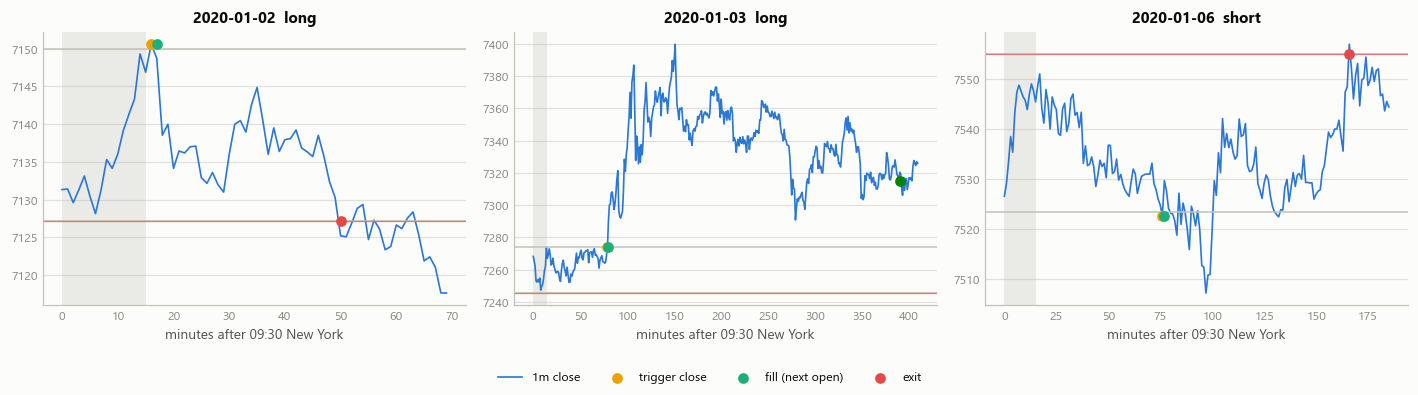

,date,H,L,trigger_idx,side,fill_utc,fill_px,stop_px,exit_utc,exit_px,exit_reason,gross_bp,risk_bp
0,2020-01-02,7150.00,7127.19,2326.0,1.0,2020-01-02 14:47:00+00:00,7150.59,7127.19,2020-01-02 15:20:00+00:00,7127.19,stop,-32.724572,32.724572
1,2020-01-03,7273.82,7245.49,3829.0,1.0,2020-01-03 15:50:00+00:00,7274.00,7245.49,2020-01-03 21:00:00+00:00,7315.05,time,56.433874,39.194391
2,2020-01-06,7555.00,7523.43,8146.0,-1.0,2020-01-06 15:47:00+00:00,7522.70,7555.00,2020-01-06 17:16:00+00:00,7555.00,stop,-42.936712,42.936712


In [4]:
led = pd.read_csv(RESULTS / "run_v1/development/BTCUSDT/P0.csv.gz")
sample = led[led.status == "trade"].head(3)
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), sharey=False)
for ax, (_, t) in zip(axes, sample.iterrows()):
    i0 = mkt.index(int(t.t0_ms)); end = int(t.exit_idx) + 20
    x = (np.arange(i0, end) - i0)
    ax.plot(x, mkt.close[i0:end], color=SERIES[0], linewidth=1.1, label="1m close")
    ax.axvspan(0, 15, color=NEUTRAL, alpha=0.25, linewidth=0)
    ax.axhline(t.H, color=AXIS, linewidth=1); ax.axhline(t.L, color=AXIS, linewidth=1)
    k, f, e = int(t.trigger_idx) - i0, int(t.fill_idx) - i0, int(t.exit_idx) - i0
    ax.scatter([k], [mkt.close[int(t.trigger_idx)]], s=36, color=SERIES[3], zorder=3, label="trigger close")
    ax.scatter([f], [t.fill_px], s=36, color=SERIES[2], zorder=3, label="fill (next open)")
    ax.scatter([e], [t.exit_px], s=36, color=NEGATIVE if t.gross_bp < 0 else SERIES[5], zorder=3, label=f"exit ({t.exit_reason})")
    ax.axhline(t.stop_px, color=NEGATIVE, linewidth=0.9, alpha=0.6)
    style(ax); ax.set_title(f"{t.date}  {'long' if t.side > 0 else 'short'}", fontsize=10)
    ax.set_xlabel("minutes after 09:30 New York")
handles, names = axes[0].get_legend_handles_labels()
fig.legend(handles, [n.split(" (")[0] if n.startswith("exit") else n for n in names], ncol=4, loc="lower center", fontsize=8)
plt.tight_layout(rect=(0, 0.08, 1, 1)); plt.show()
cols = ["date", "H", "L", "trigger_idx", "side", "fill_utc", "fill_px", "stop_px", "exit_utc", "exit_px", "exit_reason", "gross_bp", "risk_bp"]
sample[cols]

In [5]:
t = sample.iloc[0]
k = int(t.trigger_idx)
bars = pd.DataFrame({"utc": pd.to_datetime([mkt.time_ms(i) for i in range(k - 1, k + 3)], unit="ms"),
                     "open": mkt.open[k - 1:k + 3], "high": mkt.high[k - 1:k + 3], "low": mkt.low[k - 1:k + 3], "close": mkt.close[k - 1:k + 3]})
print(f"{t.date}: H={t.H}, L={t.L}. The trigger bar is the first to CLOSE above H; the fill is the next bar's OPEN ({t.fill_px}).")
bars

2020-01-02: H=7150.0, L=7127.19. The trigger bar is the first to CLOSE above H; the fill is the next bar's OPEN (7150.59).


,utc,open,high,low,close
0,2020-01-02 14:45:00,7149.32,7150.00,7144.80,7146.89
1,2020-01-02 14:46:00,7146.95,7154.06,7146.95,7150.59
2,2020-01-02 14:47:00,7150.59,7152.30,7148.23,7148.73
3,2020-01-02 14:48:00,7148.73,7148.74,7137.08,7138.54


## 4. No built-in bias

Two end-to-end runs of every stage on a synthetic random walk (`tests/test_run_smoke.py`, opt-in because each
takes about 80 seconds) confirmed that the pipeline completes, never overwrites a freeze, and handles a
challenger and an opened lockbox. On the random walk P0's gross expectancy was +2.7 bp with a standard error of
2.4 bp, and the clock-only controls are shown below: a strategy engine without an edge in its data shows none.

In [6]:
mech = json.loads((RESULTS / "run_v1/exploratory/mechanism.json").read_text())
pd.DataFrame(mech["random_walk_engine_check"]).T

,trades,gross_mean_bp,se_bp
CTL_CLOCK_LONG,1670.0,0.973437,1.110786
CTL_CLOCK_SHORT,1670.0,1.488358,1.157003
P0,1668.0,2.331603,1.583943
